# Different Selection strategies (UCB, UCB-Tuned, RAVE, n-grams)

In [1]:
# import external libraries
from qiskit import qpy
import evaluation_functions as evf
import mcts_group_selection as mcts
from structure import Circuit
import itertools
import os
# import seaborn as sns
from tqdm import tqdm
import csv
# import functions, classes and objects

In [2]:
#reload kernal for changes in file
import importlib
importlib.reload(mcts)

<module 'mcts_group_selection' from '/Users/geordangesink/Documents/Uni/BTR/code/my-code/mcts_group_selection.py'>

In [3]:
num_runs = 10
params = {
    'collect_data': [True],
    'evaluation_function': [evf.h2, evf.lih, evf.h2o, evf.vqls_0, evf.vqls_1],
    # 'choices': [{'a': 20, 'd': 20, 's': 20, 'c': 20, 'p': 20}],
    # 'stop_deterministic': [False],


 # TEST BEST ONES

# Change from here
    'group_by_gates': [False],
    'group_by_action': [True],
    'terminal_nodes': [False],
    'group_by_change': [False],
    'group_by_swap': [False],
    'finite_progressive_widening': [True],

    'selection_method': ['RAVE-0.5'],
    'n': [3],
}
# name = 'selection-UCB'
# name = 'selection-UCB_tuned'
# name = 'selection-RAVE'
name = 'selection-RAVE_0.5'

In [4]:
nqbits = {'h2': 4, 'lih': 10, 'h2o': 8,'vqls_1': 4,'vqls_0': 4}
budgets = {'h2': 5000, 'lih': 5000, 'h2o': 5000,'vqls_1': 5000,'vqls_0': 5000}
keys = list(params)
results_folder = 'results'

def test_all_vars_one_problem(max_depth, verbose=False):   
    count = 0 
    for values in tqdm(itertools.product(*map(params.get,keys))):
        count += 1
        print(values)
        for i in range(num_runs):
            evf = values[1]
            evf_name = evf.__name__
            print(evf_name, count)
            folder_name = f"{results_folder}/{name}/{evf_name}"
            os.makedirs(folder_name, exist_ok=True)  # Create the folder if it doesn't exist
            filename = f"{name}_{i}.csv"
            csv_path = os.path.join(folder_name, filename)
            if not os.path.isfile(csv_path):
                root = mcts.Node(Circuit(variable_qubits=nqbits[evf_name], ancilla_qubits=0), max_depth=max_depth)
                results = mcts.mcts(root, **dict(zip(keys,values)), budget=budgets[evf_name], verbose=verbose)
                objective_values = results['data'] 
                objective_values.to_csv(csv_path, index=False)

                qc_last = results['qc'][-1]
                qc_best = results['best_qc']
                data = [
                    ["Category", "EnergyBefore", "ValueBefore", "EnergyAfter", "ValueAfter", "H", "Cx", "Rx", "Ry", "Rz"]
                ]
                for id, circ in {"last": qc_last, "best": qc_best}.items():
                    arr = []
                    with open(f"{results_folder}/{name}/{evf_name}/{name}_{i}_{id}_circuit.qpy", "wb") as file:
                        qpy.dump(circ, file)
                    optim = [evf(quantum_circuit=circ)] if "vqls_0" in evf_name else evf(quantum_circuit=circ, gradient=True)
                    energy_before = optim[0]
                    value_before = -energy_before    
                    energy_after = optim[-1]
                    value_after = -energy_after    
                    gate_counts = dict(circ.count_ops())
                    h_gates = gate_counts["h"] if "h" in gate_counts.keys() else 0
                    cx_gates = gate_counts["rx"] if "rx" in gate_counts.keys() else 0
                    rx_gates = gate_counts["ry"] if "ry" in gate_counts.keys() else 0
                    ry_gates = gate_counts["rz"] if "rz" in gate_counts.keys() else 0
                    rz_gates = gate_counts["cx"] if "cx" in gate_counts.keys() else 0
                    arr = [id, energy_before, value_before, energy_after, value_after, h_gates, cx_gates, rx_gates, ry_gates, rz_gates]
                    data.append(arr)

                with open(f"{results_folder}/{name}/{evf_name}/{name}_{i}_optimized.csv", mode='w', newline='', encoding='utf-8') as file:
                    writer = csv.writer(file)
                    writer.writerows(data)
        
test_all_vars_one_problem(10, False)

0it [00:00, ?it/s]

(True, <function h2 at 0x15bf92480>, False, True, False, False, False, True, 'RAVE-0.5', 3)
h2 1
h2 1
h2 1
h2 1
h2 1
h2 1
h2 1
h2 1
h2 1
h2 1
(True, <function lih at 0x31ee4ef20>, False, True, False, False, False, True, 'RAVE-0.5', 3)
lih 2
lih 2
lih 2
lih 2
lih 2
lih 2
lih 2
lih 2
lih 2
lih 2
(True, <function h2o at 0x31ee4ea20>, False, True, False, False, False, True, 'RAVE-0.5', 3)
h2o 3
h2o 3
h2o 3
h2o 3
h2o 3
h2o 3
h2o 3
h2o 3
h2o 3
h2o 3
(True, <function vqls_0 at 0x31ee4f600>, False, True, False, False, False, True, 'RAVE-0.5', 3)
vqls_0 4
vqls_0 4
vqls_0 4
vqls_0 4
vqls_0 4
vqls_0 4
vqls_0 4
vqls_0 4
vqls_0 4
vqls_0 4


4it [1:00:15, 903.95s/it]

(True, <function vqls_1 at 0x31edc0040>, False, True, False, False, False, True, 'RAVE-0.5', 3)
vqls_1 5

Final value of the cost function is  0.1357 
Landscape is flat

Final value of the cost function is  0.0135 
vqls_1 5

Final value of the cost function is  0.2267 
Landscape is flat

Final value of the cost function is  0.0135 
vqls_1 5

Final value of the cost function is  0.2925 
Landscape is flat

Final value of the cost function is  0.0135 
vqls_1 5

Final value of the cost function is  0.1027 
Landscape is flat

Final value of the cost function is  0.0135 
vqls_1 5


/opt/homebrew/lib/python3.11/site-packages/autograd/tracer.py:14: UserWarning: Output seems independent of input.
  warnings.warn("Output seems independent of input.")



Final value of the cost function is  0.2145 
Landscape is flat

Final value of the cost function is  0.0135 
vqls_1 5

Final value of the cost function is  0.2527 
Landscape is flat

Final value of the cost function is  0.0135 
vqls_1 5


/opt/homebrew/lib/python3.11/site-packages/autograd/tracer.py:14: UserWarning: Output seems independent of input.
  warnings.warn("Output seems independent of input.")


Landscape is flat

Final value of the cost function is  0.1759 
Landscape is flat

Final value of the cost function is  0.0135 
vqls_1 5

Final value of the cost function is  0.2500 
Landscape is flat

Final value of the cost function is  0.0135 
vqls_1 5

Final value of the cost function is  0.0141 
Landscape is flat

Final value of the cost function is  0.0135 
vqls_1 5

Final value of the cost function is  0.0295 


5it [4:25:11, 3182.38s/it]


Final value of the cost function is  0.0008 


# Add to JSON

In [5]:
import analysing_utils

results = analysing_utils.load_circuit_results()

In [6]:
def copy_without_qc(data):
    """Recursively copy the dictionary while excluding keys named 'qc'."""
    if isinstance(data, dict):
        # Process each key-value pair in the dictionary
        return {key: copy_without_qc(value) for key, value in data.items() if key != "qc"}
    elif isinstance(data, list):
        # Process each element in the list
        return [copy_without_qc(item) for item in data]
    else:
        # Return the value directly if it's not a list or dictionary
        return data

In [7]:
import numpy as np

def convert_ndarray_to_list(data):
    if isinstance(data, dict):
        return {key: convert_ndarray_to_list(value) for key, value in data.items()}
    elif isinstance(data, list):
        return [convert_ndarray_to_list(item) for item in data]
    elif isinstance(data, np.ndarray):
        return data.tolist()
    else:
        return data

In [8]:
filtered_dict = convert_ndarray_to_list(copy_without_qc(results))

In [9]:
import json 

with open("results.json", "w") as outfile: 
    json.dump(filtered_dict, outfile)

# Plotting

In [10]:
import analysing_utils
import matplotlib.pyplot as plt

In [11]:
results = analysing_utils.load_mcts_results()
print(results)

{'h2o': {'selection-1_grams': [      budget expandedBy  objectiveValue   epoch  treeDepth  parentValue    H  \
0        0.0        NaN       74.555902     0.0        0.0     0.000000  8.0   
1        1.0        add       74.555902     1.0        1.0    74.555902  8.0   
2        2.0     delete       74.622342     1.0        1.0    74.555902  7.0   
3        3.0       swap       74.622342     1.0        1.0    74.555902  7.0   
4        4.0        add       74.555902     2.0        2.0    74.555902  8.0   
...      ...        ...             ...     ...        ...          ...  ...   
4996  4996.0     delete       74.832254  3977.0      373.0    74.687947  0.0   
4997  4997.0        add       74.670145  3978.0      388.0    74.755606  0.0   
4998  4998.0        add       74.839567  3979.0      196.0    74.628379  0.0   
4999  4999.0        add       74.937488  3980.0      404.0    75.002863  0.0   
5000  5000.0        add       74.446727  3981.0      403.0    74.837997  0.0   

       R

In [12]:
problems = ["h2", "h2o", "lih", "vqls_0", "vqls_1"]
optimal_value = {"h2": 1.117, "h2o": 75.4217, "lih": 7.973, "vqls_0": 0, "vqls_1": 0}

In [15]:
variants = [ 'selection-UCB', 'selection-UCB_tuned', 'selection-RAVE', 'selection-RAVE_0.5', 'selection-1_grams', 'selection-2_grams', 'selection-3_grams', 'selection-UCB_tuned-1.41', 'selection-UCB_tuned-0.4']

In [16]:
convergence = analysing_utils.converge_all(results, problems, variants)

In [17]:
color_palette =  {
    "selection-UCB": 'red',
    "selection-UCB_tuned": 'green',
    'selection-UCB_tuned-1.41': 'lime',
    'selection-UCB_tuned-0.4': 'cyan',
    "selection-RAVE": 'blue',
    'selection-RAVE_0.5': 'beige',
    'selection-1_grams': 'black',
    'selection-2_grams': 'pink',
    'selection-3_grams': "purple",
}

baseline = None

#### Plot:

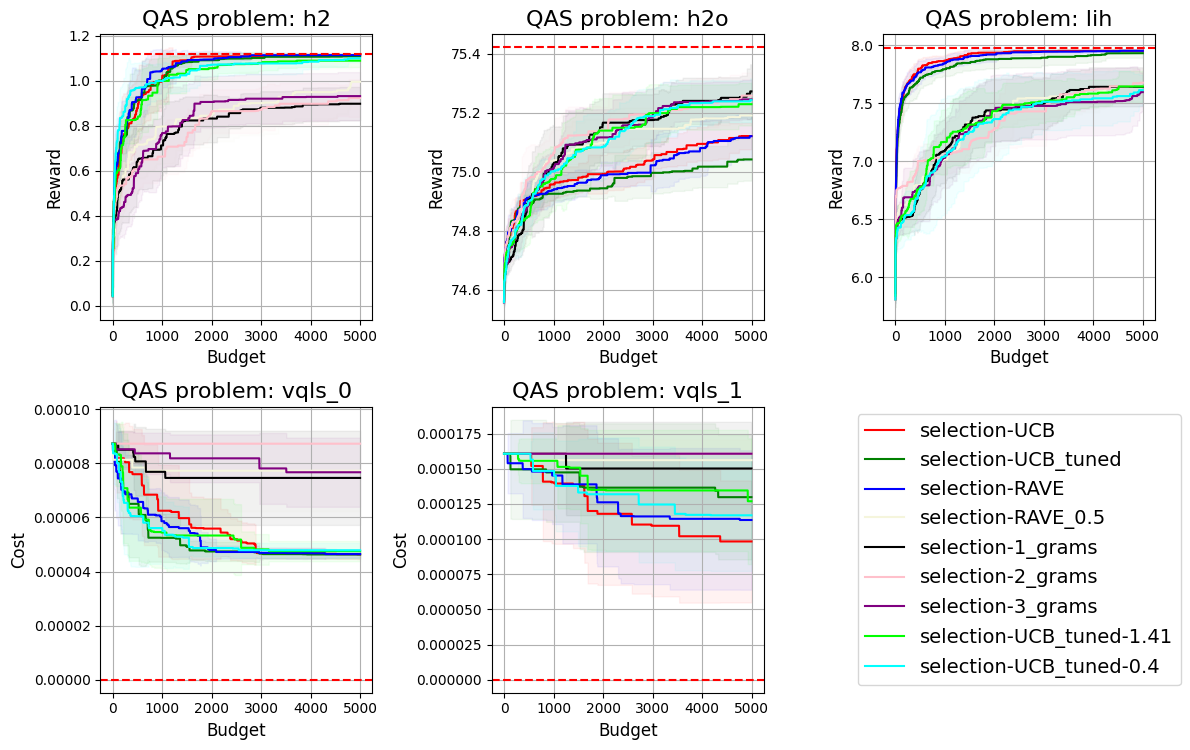

In [18]:
analysing_utils.plot_figure(problems, variants, optimal_value, convergence, color_palette, baseline)

#### Boxplot

In [18]:
import analysing_utils
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
variants = [
    'selection-UCB',
    'selection-UCB_tuned', 
    'selection-RAVE', 
    'RAVE-1.41', 
    'selection-1_grams', 
    'selection-2_grams', 
    'selection-3_grams',
    'selection-UCB_tuned-1.41', 
    'selection-UCB_tuned-0.4'
]
problems = ['h2', 'h2o', 'lih', 'vqls_0', 'vqls_1']
vql_problems = ['vqls_0', 'vqls_1']
chemistry_problems = ['h2', 'h2o', 'lih']
optimal_value = {'h2': 1.117, 'h2o': 75.42175236224648, 'lih': 7.95265005, 'vqls_0': 1, 'vqls_1': 1}

In [114]:
split_variants = []
for variant in variants:
    split_variants = split_variants + variant.split('_')
unique_vars = list(set(split_variants))
unique_vars

table_df = pd.DataFrame(columns=unique_vars)
table_df.head()

for variant in variants:
    variant.split('_')
    for col in unique_vars:
        table_df.at[variant, col] = 1 if col in variant.split('_') else 0

In [115]:
results = analysing_utils.load_mcts_results()

In [116]:
circuit_results = analysing_utils.load_circuit_results()
print(circuit_results)

{'h2o': {'selection-5_grams': [75.42175221258553, 75.42175238187785, 75.31712458874763, 75.32922792932311, 75.34580237445655, 75.4064931037464, 75.42175240277976, 75.34529445780754, 75.42175237978697, 75.34580240971165], 'selection-1_grams': [75.34580254659247, 75.34580259129707, 75.4217521029106, 75.29322776040168, 75.34579670548608, 75.42175227977013, 75.31712462591673, 75.40649310820262, 75.2659626454463, 75.34580252059924], 'selection-n_grams': [75.42175152304445, 75.42175241015609, 75.373874167878, 75.42175232533152, 75.42175240718554, 75.36943849618683, 75.37389826855872, 75.3899261628149, 75.36336986857489, 75.42175240272276], 'selection-3_grams': [75.4217503542587, 75.42175238500326, 75.31712463918373, 75.3452942159966, 75.42175238315157, 75.42175234757522, 75.2659622073283, 75.42175240659846, 75.42175241153599, 75.34580256453891], 'selection-2_grams': [75.42175239080369, 75.26596266262399, 75.34580259328074, 75.42175238684962, 75.34580257589604, 75.42175237898785, 75.421752390

In [117]:
problem_stats = {}
for problem in problems:
    problem_results = []
    for variant in variants:
        problem_results.append(circuit_results[problem][variant])
    print('finished')
    print(problem_results)
    problem_stats[problem] =  analysing_utils.standardize_problem_stats(problem_results)
    print(problem_stats[problem])
print(circuit_results)
problem_stats
# IDK what this does
# analysing_utils.standardize_from_stats(problem_stats["h2"], circuit_results["h2"]["gates"][0])

finished
[[1.1173490283616343, 1.1173490341636998, 1.1173490036030582, 1.1173490017792973, 1.1173490315348034, 1.1173490030517688, 1.1173490342649233, 1.11734902983555, 1.1173490331542502, 1.1173490242886597], [1.1173489853158498, 1.117349034318721, 1.117348931954399, 1.1173490255998917, 1.1173490058944897, 1.117349015778086, 1.1173490313406589, 1.11734875139684, 1.117349009222551, 1.1173484579609163], [1.1173490312599876, 1.117348996218432, 1.1173490308835228, 1.1173490336015874, 1.1173489944286843, 1.117341836920026, 1.1173490062155986, 1.1173485978218491, 1.1173490349155326, 1.1173484546502963], [1.1173490240472617, 1.1173488329593306, 1.1173490330387812, 1.1173488913008438, 1.1173488830573353, 1.1173490191773665, 1.117348867451084, 1.117348999110458, 1.1173479976046123, 1.1173482879781933], [1.117349030256903, 1.11734903036828, 1.1173490306926834, 1.117348899331062, 1.117348869289858, 1.1173489092849551, 1.1173490099944408, 1.117349024477288, 1.1173490274291744, 1.1173489627859172]

{'h2': {'mean': 1.118033910540686,
  'std': 0.0035267772251707996,
  'min': 1.117341836920026,
  'max': 1.136189416613094},
 'h2o': {'mean': 75.30895064314893,
  'std': 0.12355878253947417,
  'min': 74.95669172813756,
  'max': 75.42175241153599},
 'lih': {'mean': 7.901103234613532,
  'std': 0.0738765059720004,
  'min': 7.641560951825339,
  'max': 7.9526500454457505},
 'vqls_0': {'mean': 0.8232176885092585,
  'std': 0.19659494144777542,
  'min': 0.5202975886223685,
  'max': 0.9999995468239383},
 'vqls_1': {'mean': 0.9057681665571031,
  'std': 0.06037121735736458,
  'min': 0.7454264419247875,
  'max': 0.9999999821161007}}

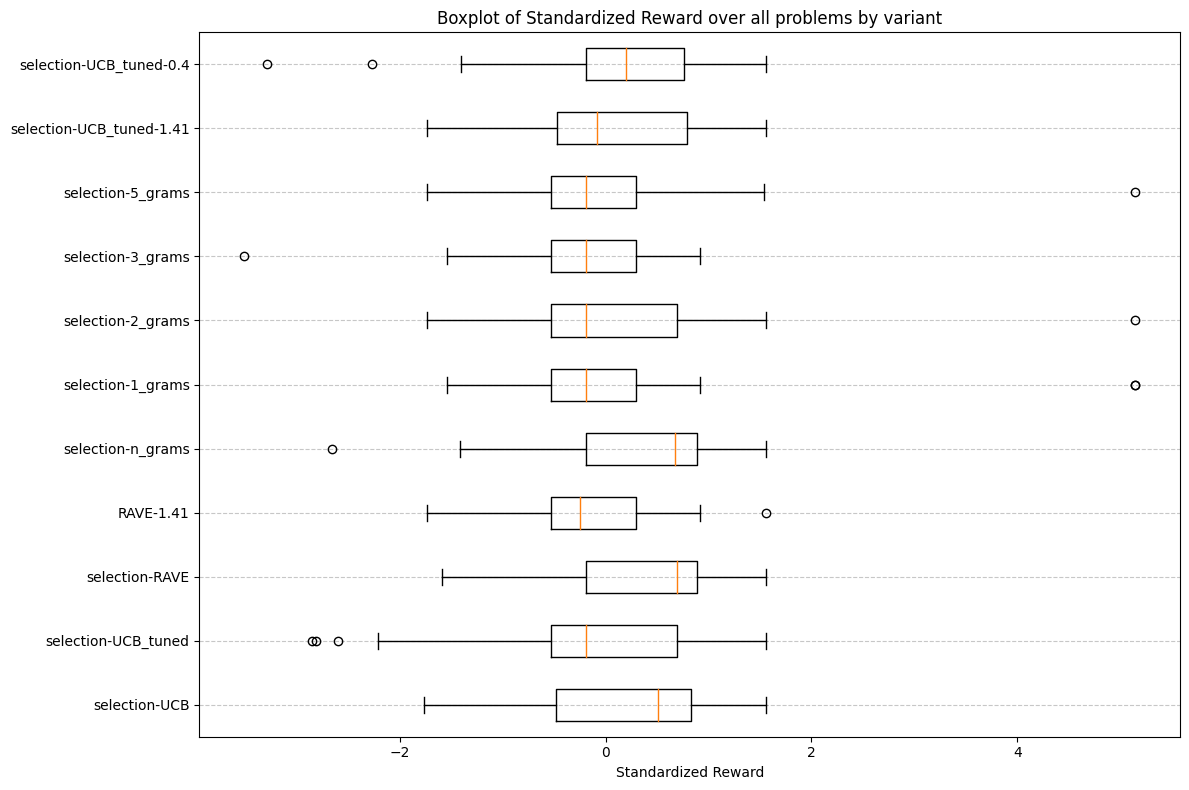

In [118]:
variant_results = {}
for variant in variants:
    standardized_results = []
    for problem in problems:
        for run in circuit_results[problem][variant]:
            result = analysing_utils.standardize_from_stats(problem_stats[problem], run)
            standardized_results.append(result)
    variant_results[variant] = standardized_results

variant_results
plt.figure(figsize=(12, 8))
plt.boxplot(variant_results.values(), labels=variant_results.keys(), vert=False)
plt.xlabel('Standardized Reward')
plt.title('Boxplot of Standardized Reward over all problems by variant')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal grid lines
plt.show()

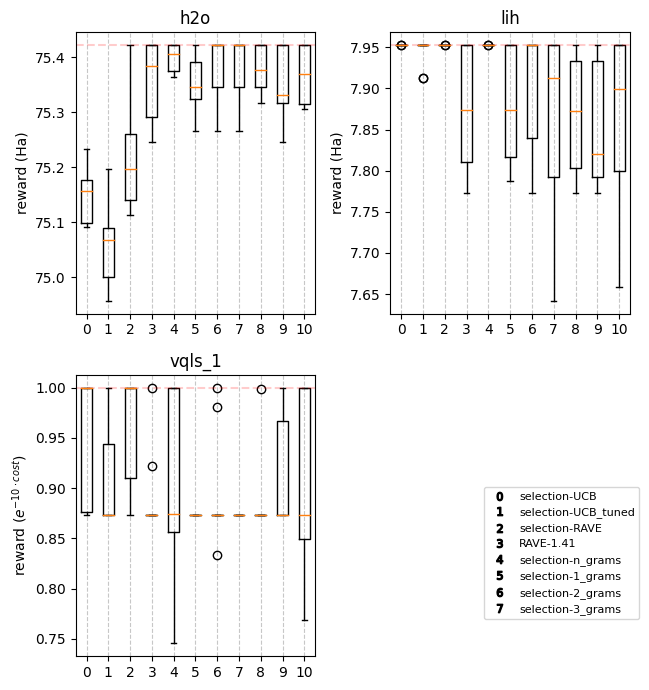

In [119]:
# curate = ['standard_nc_prob','terminal_nc', 'gates', 'gates_terminal', 'actions', 'actions_change_gates_swap', 'actions_change_gates_swap_terminal','actions_pw_terminal']
curate = variants
circuit_results_curated = {problem: {key: circuit_results[problem][key] for key in curate if key in circuit_results[problem]} for problem in problems}

problems_curated = problems.copy()
# removing vqls_0 and h2 for now
problems_curated.remove('vqls_0')
problems_curated.remove('h2')
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(6.5, 7))
axes = axes.flatten()

for i, problem in enumerate(problems_curated):
    ax = axes[i]
    ax.boxplot(circuit_results_curated[problem].values(), labels=range(len(circuit_results_curated[problem].keys())))
    ax.axhline(y=optimal_value[problem], color='red', linestyle='--', alpha=0.2)
    ax.set_title(f"{problem}")
    if problem in ['h2o', 'lih']:
        ax.set_ylabel("reward (Ha)")
    else:
        ax.set_ylabel(r"reward ($e^{-10 \cdot cost}$)")
    ax.grid(axis='x', linestyle='--', alpha=0.7)  # Add horizontal grid lines

# labels = ['Baseline', 'Baseline with Terminal', 'Group By Gates','Group By Gates with Terminal Nodes', 'Group By Actions', 'All Groupings', 'All Groupings with Terminal Nodes', 'Group by Actions with Progressive \nWidening and Terminal Nodes']
labels = variants
import matplotlib.lines as mlines

# Create dummy handles for the legend
handles = [mlines.Line2D([], [], color='black', marker=f'${i}$', linestyle='None') for i in range(8)]
fig.legend(handles, labels, loc='lower right', ncol=1, bbox_to_anchor=(1, 0.1), prop={'size': 8})  
axes[-1].axis('off')  # Hide the last subplot
plt.tight_layout()
plt.show()


['selection-UCB', 'selection-UCB_tuned', 'selection-RAVE', 'RAVE-1.41', 'selection-n_grams', 'selection-1_grams', 'selection-2_grams', 'selection-3_grams', 'selection-5_grams', 'selection-UCB_tuned-1.41', 'selection-UCB_tuned-0.4']
{'selection-5_grams': [1.117349032119342, 1.1173481887557084, 1.1173489981893314, 1.1173490336701717, 1.1173489968877597, 1.1173490345424353, 1.1173490173509626, 1.117348940567616, 1.1173490300355369, 1.136189416613094], 'selection-1_grams': [1.1173489824952303, 1.11734875803375, 1.1173490090448692, 1.117349024248341, 1.1173490119215357, 1.1361885257014932, 1.1361890762342275, 1.1173490330108793, 1.117349014871074, 1.1173490048696004], 'selection-n_grams': [1.117349030256903, 1.11734903036828, 1.1173490306926834, 1.117348899331062, 1.117348869289858, 1.1173489092849551, 1.1173490099944408, 1.117349024477288, 1.1173490274291744, 1.1173489627859172], 'selection-3_grams': [1.11734902412643, 1.1173489132308614, 1.1173490293564798, 1.1173489886362231, 1.117348881

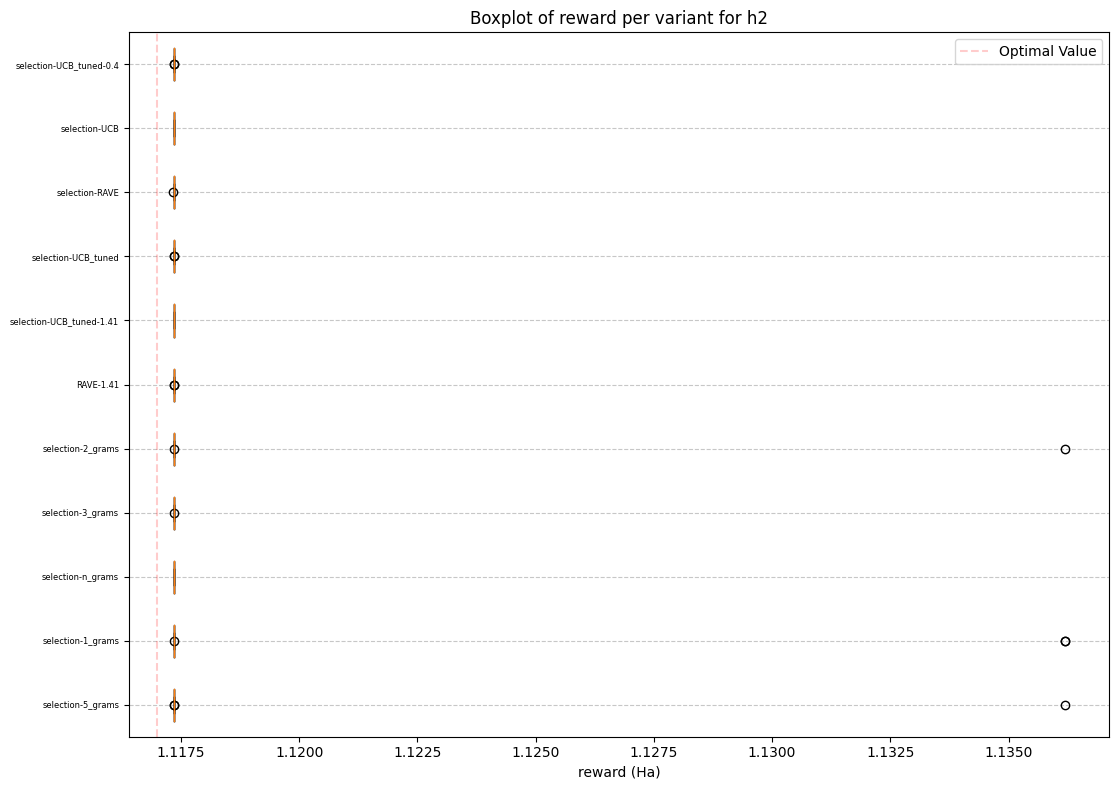

{'selection-5_grams': [75.42175221258553, 75.42175238187785, 75.31712458874763, 75.32922792932311, 75.34580237445655, 75.4064931037464, 75.42175240277976, 75.34529445780754, 75.42175237978697, 75.34580240971165], 'selection-1_grams': [75.34580254659247, 75.34580259129707, 75.4217521029106, 75.29322776040168, 75.34579670548608, 75.42175227977013, 75.31712462591673, 75.40649310820262, 75.2659626454463, 75.34580252059924], 'selection-n_grams': [75.42175152304445, 75.42175241015609, 75.373874167878, 75.42175232533152, 75.42175240718554, 75.36943849618683, 75.37389826855872, 75.3899261628149, 75.36336986857489, 75.42175240272276], 'selection-3_grams': [75.4217503542587, 75.42175238500326, 75.31712463918373, 75.3452942159966, 75.42175238315157, 75.42175234757522, 75.2659622073283, 75.42175240659846, 75.42175241153599, 75.34580256453891], 'selection-2_grams': [75.42175239080369, 75.26596266262399, 75.34580259328074, 75.42175238684962, 75.34580257589604, 75.42175237898785, 75.42175239028414, 7

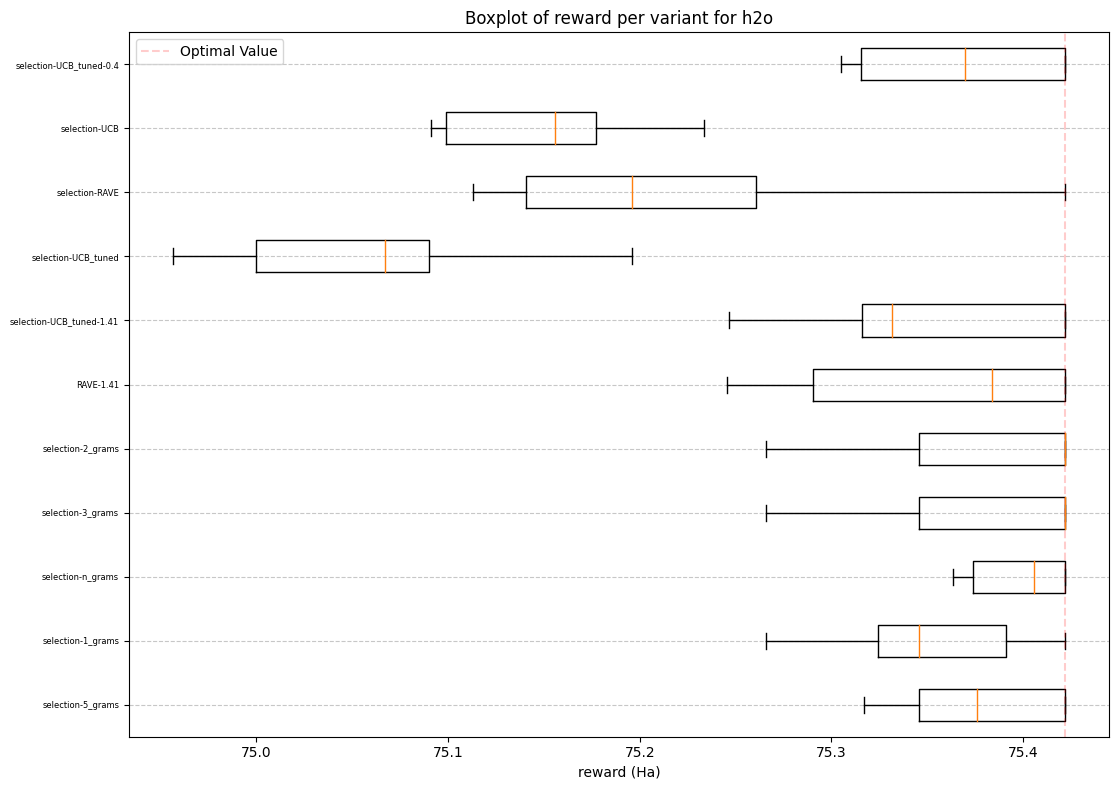

{'selection-5_grams': [7.873824406321409, 7.797170962745674, 7.952649954878628, 7.871317096482284, 7.952649983245087, 7.952645055824639, 7.873824581667693, 7.773195094676878, 7.797170847557884, 7.823509867484555], 'selection-1_grams': [7.952650044511352, 7.95264997073732, 7.809133730301664, 7.787687379886856, 7.809133718295666, 7.952650045432504, 7.873824597922247, 7.873824570676821, 7.838558620386228, 7.952117506001006], 'selection-n_grams': [7.952650045445749, 7.952650045445749, 7.952650045445747, 7.952650045445747, 7.952649981328585, 7.9526500454457505, 7.952650045445749, 7.952649936946852, 7.952650045445748, 7.952650045445748], 'selection-3_grams': [7.952650005995438, 7.952650033798271, 7.789984118962506, 7.952650028876052, 7.873824531731345, 7.641560951825339, 7.797170963719332, 7.789984143728879, 7.952649982085095, 7.952649932748311], 'selection-2_grams': [7.952649963805713, 7.952650039167366, 7.952650019595581, 7.952649991021743, 7.952649967453273, 7.873824620614813, 7.809133512

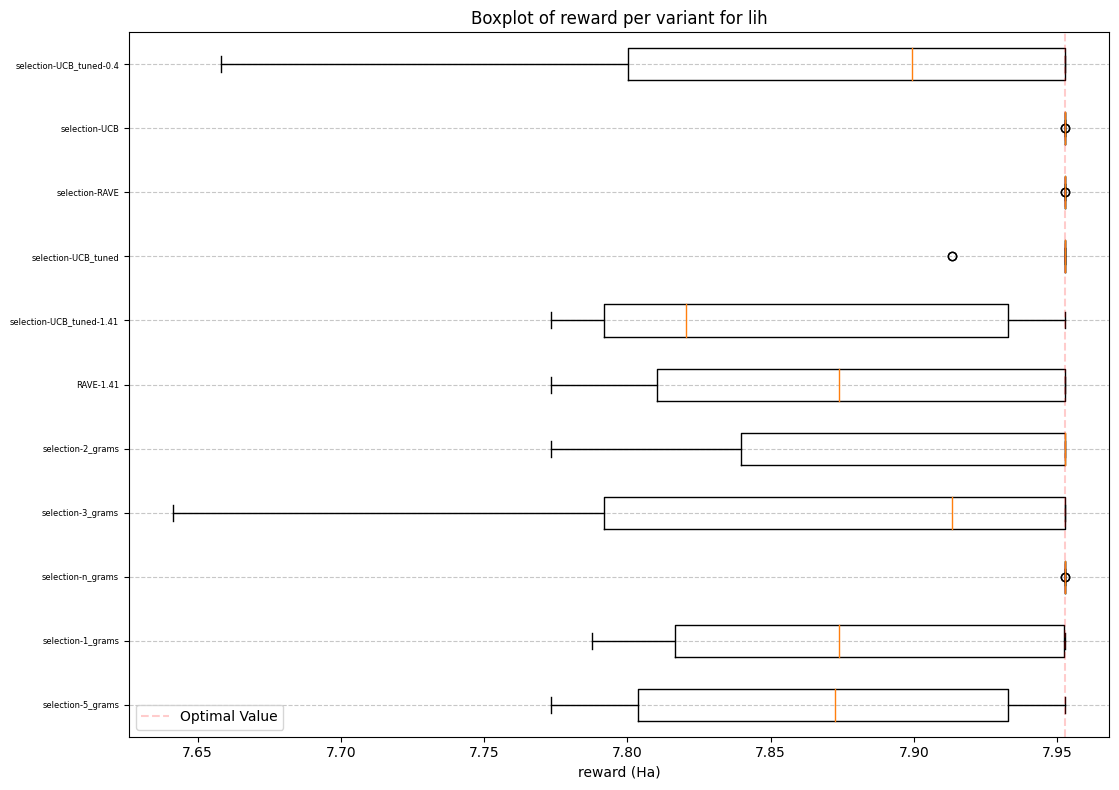

{'selection-5_grams': [0.5202975886223685, 0.6304175537952708, 0.7159660249252384, 0.6917054729797304, 0.5202975886223685, 0.9988126226408158, 0.5202975886223685, 0.520297588622375, 0.5202975886223685, 0.7979770356479698], 'selection-1_grams': [0.520297588622375, 0.9046704688104611, 0.5202975886223685, 0.5202975886223685, 0.7057766443755192, 0.520297588622375, 0.8919128109666487, 0.8571403346265074, 0.5656202305717138, 0.7529662556773242], 'selection-n_grams': [0.9963976572560094, 0.8357341886730894, 0.9390949912568962, 0.9598140290834621, 0.9994720382162807, 0.920257307734785, 0.9999303018457775, 0.9430823680494632, 0.9999802722208551, 0.9999995468239383], 'selection-3_grams': [0.539871970162569, 0.520297588622375, 0.520297588622375, 0.8932303384907799, 0.5202975886223685, 0.5547352639210181, 0.7515154268062582, 0.8441483748151335, 0.626816246599182, 0.8420712057142805], 'selection-2_grams': [0.8956133466599395, 0.5202975886223685, 0.5202975886223685, 0.8253261074098306, 0.52029758862

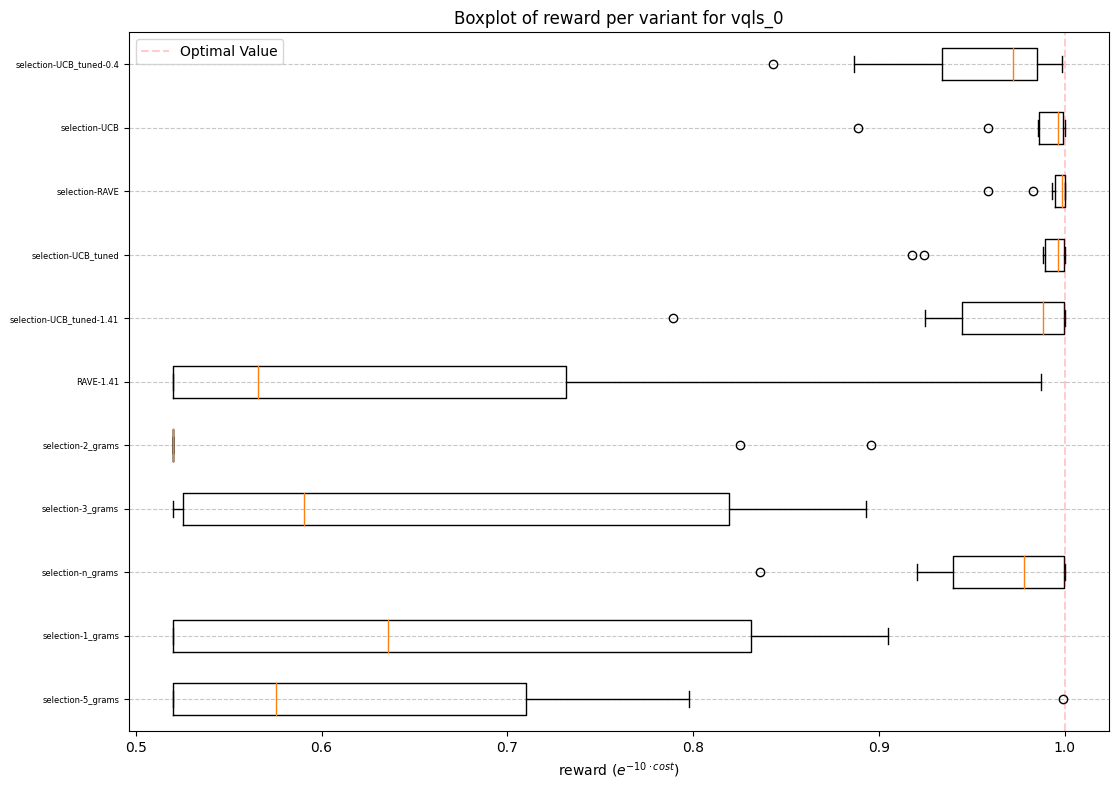

{'selection-5_grams': [0.8735978499475605, 0.8735978499475588, 0.9988089660101812, 0.8735978499475588, 0.8735978499475588, 0.8735978499475588, 0.8735978499475588, 0.8735978499475605, 0.8735978499475588, 0.8735978499475588], 'selection-1_grams': [0.8735978499475605, 0.8735978499475605, 0.8735978499475588, 0.8735978499475588, 0.8735978499475588, 0.8735978499475605, 0.8735978499475605, 0.8735978499475605, 0.8735978499475605, 0.8735978499475605], 'selection-n_grams': [0.9997457720663622, 0.8735978499475588, 0.8506474040436578, 0.8735978499475605, 0.8745698390154788, 0.8202497567032975, 0.7454264419247875, 0.9999999821161007, 0.9999976611929564, 0.9998777636822086], 'selection-3_grams': [0.8735978499475588, 0.8735978499475588, 0.8735978499475605, 0.8735978499475605, 0.8735978499475605, 0.8735978499475605, 0.8735978499475588, 0.8735978499475605, 0.8735978499475588, 0.8735978499475588], 'selection-2_grams': [0.9806030131580611, 0.8735978499475605, 0.8735978499475588, 0.8735978499475605, 0.999

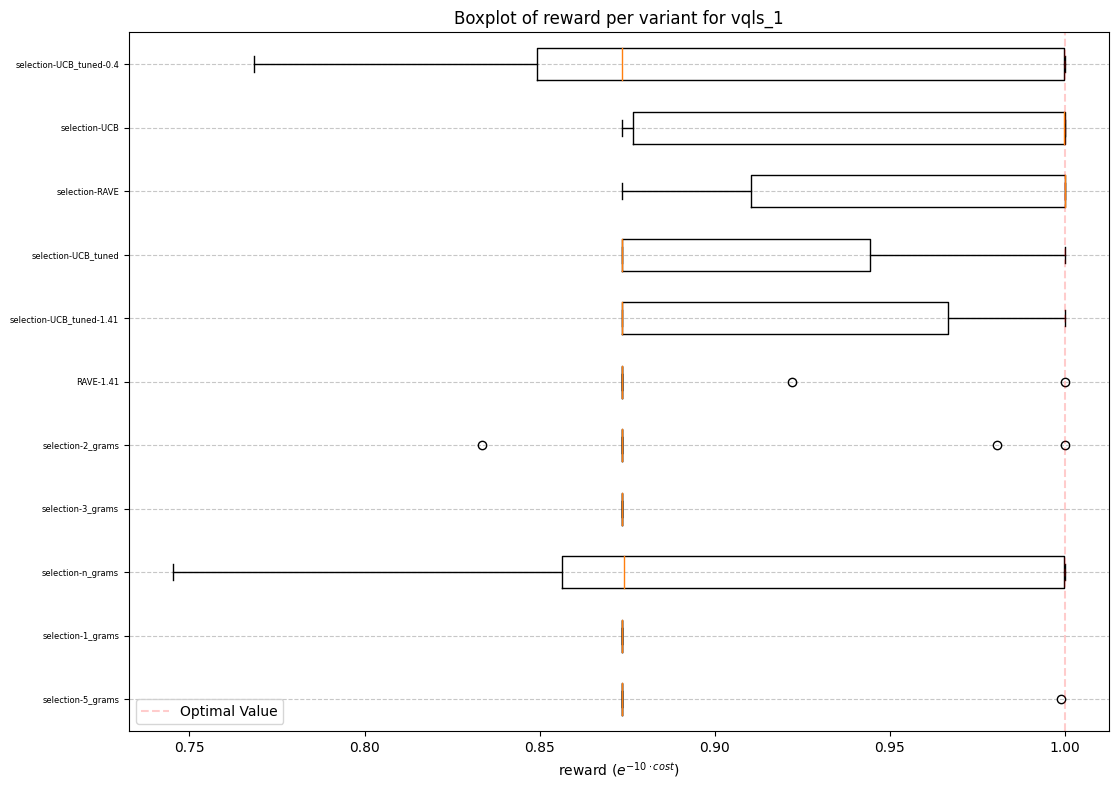

In [120]:
labels= variants
print(labels)
for problem in problems:
    
    plt.figure(figsize=(12, 8))
    print(circuit_results[problem])
    plt.boxplot(circuit_results[problem].values(), labels=circuit_results[problem].keys(), vert=False)
    plt.axvline(x=optimal_value[problem], color='red', linestyle='--', label='Optimal Value', alpha=0.2)
    if problem in ['h2', 'h2o', 'lih']:
        plt.xlabel("reward (Ha)")
    else:
        plt.xlabel(r"reward ($e^{-10 \cdot cost}$)")
    plt.title(f"Boxplot of reward per variant for {problem}")
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal grid lines
    plt.legend()
    plt.yticks(fontsize=6)
    plt.show()